In [1]:
import xarray as xr
from glob import glob
from pathlib import Path
from matplotlib import pyplot as plt
from dask.distributed import Client
from utils import compute_rmse

In [2]:
reconstruction_files = sorted(glob("metrics/deterministic/reconstruction*"))
forecast_files = sorted(glob("metrics/deterministic/forecast*"))

In [3]:
reconstructions = {}
for file in reconstruction_files:
    path = Path(file)
    name = path.name.split(".")[0]
    name = name.split("rmse_")[-1]
    reconstructions[name] = xr.open_dataarray(file)

In [4]:
forecasts = {}
for file in forecast_files:
    path = Path(file)
    name = path.name.split(".")[0]
    name = name.split("rmse_")[-1]
    forecasts[name] = xr.open_dataarray(file)

In [5]:
reconstruction_averages = []
forecast_averages = []

for key in reconstructions.keys():
    reconstruction_averages.append((key, reconstructions[key].mean().values))
    forecast_averages.append((key, forecasts[key].mean().values))

In [6]:
client = Client(processes=False)

ground_truth = xr.open_dataarray("input_data/era5_slice.zarr", engine="zarr")
climatology = xr.open_dataarray(
    "input_data/climatology_JanFeb2020.zarr", engine="zarr"
)

keys = list(forecasts.keys())
time = forecasts[keys[0]].time.values
rmse_climatology = compute_rmse(
    ground_truth.sel(time=time),
    climatology.sel(time=time),
)

client.close()

/Users/dsalvadorjasin/Documents/projects/svdrom-project/grid-search/.venv/lib/python3.12/site-packages/numcodecs/__init__.py:106: DeprecationWarning: crc32c usage is deprecated since numcodecs v0.16.4. It is recommended to install google_crc32c instead.
  from numcodecs.checksum32 import CRC32, Adler32, JenkinsLookup3


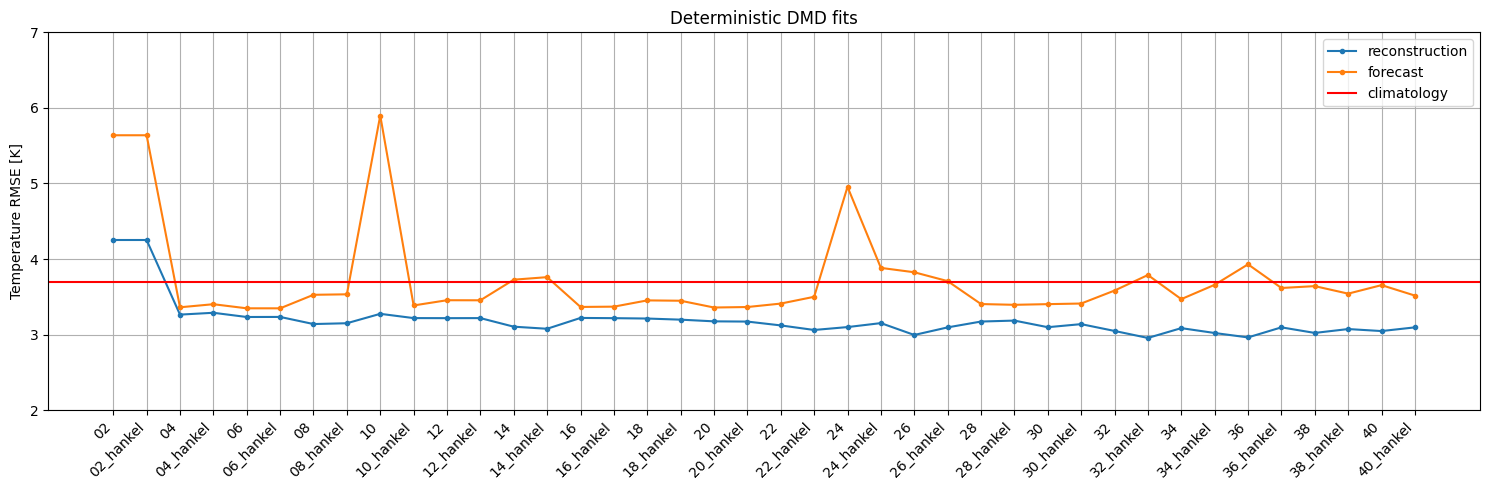

In [7]:
plt.figure(figsize=(15, 5))
keys = [key for key, _ in reconstruction_averages]
reconstruction_vals = [val for _, val in reconstruction_averages]
forecast_vals = [val for _, val in forecast_averages]
plt.plot(reconstruction_vals, ".-", label="reconstruction")
plt.plot(forecast_vals, ".-", label="forecast")
plt.xticks(
    range(len(reconstruction_vals)),
    list(keys),
    rotation=45,
    ha='right',
)
plt.ylim((2.0, 7.0))
plt.axhline(
    y=rmse_climatology.mean().values, color='r', linestyle='-', label="climatology"
)
plt.ylabel("Temperature RMSE [K]")
plt.title("Deterministic DMD fits")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
reconstruction_files = sorted(glob("metrics/probabilistic/reconstruction*"))
forecast_files = sorted(glob("metrics/probabilistic/forecast*"))

In [9]:
reconstructions = {}
for file in reconstruction_files:
    path = Path(file)
    name = path.name.split(".")[0]
    name = name.split("rmse_")[-1]
    reconstructions[name] = xr.open_dataarray(file)

In [10]:
forecasts = {}
for file in forecast_files:
    path = Path(file)
    name = path.name.split(".")[0]
    name = name.split("rmse_")[-1]
    forecasts[name] = xr.open_dataarray(file)

In [11]:
reconstruction_averages = []
forecast_averages = []

for key in reconstructions.keys():
    reconstruction_averages.append((key, reconstructions[key].mean().values))
    forecast_averages.append((key, forecasts[key].mean().values))

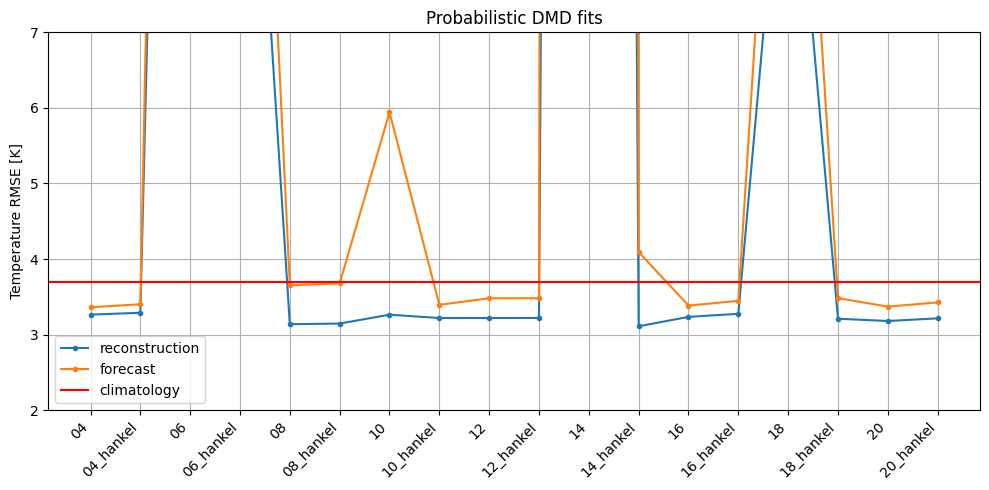

In [12]:
plt.figure(figsize=(10, 5))
keys = [key for key, _ in reconstruction_averages]
reconstruction_vals = [val for _, val in reconstruction_averages]
forecast_vals = [val for _, val in forecast_averages]
plt.plot(reconstruction_vals, ".-", label="reconstruction")
plt.plot(forecast_vals, ".-", label="forecast")
plt.xticks(
    range(len(reconstruction_vals)),
    list(keys),
    rotation=45,
    ha='right',
)
plt.ylim((2.0, 7.0))
plt.axhline(
    y=rmse_climatology.mean().values, color='r', linestyle='-', label="climatology"
)
plt.ylabel("Temperature RMSE [K]")
plt.title("Probabilistic DMD fits")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()